# Chapter 18: Final Submission Selection

**How much public evidence does it take before the public leaderboard picks as well as a local validation set?**

Late in a competition the candidates are close, and the public leaderboard is the loudest evidence available. Measuring how often it picks the best candidate tells you when to lean on it and when to lean on local, paired evidence.

*Constructed data. The sizes of the effects depend on this generator, on twelve candidates and on a 1,000-row local set; the direction (more rows pick better, pooling beats either source) is the claim, not the numbers.*

## The experiment

Five constructed binary tasks. For each, twelve gradient-boosting variants (learning rate, leaf count, L2 penalty) are fitted on 2,500 rows and scored by log loss on a pool of 12,000 further rows; the pool mean is each candidate's true loss. In each of 300 random splits per task, 2,000 pool rows form the hidden test set, divided into public rows (the control sets their share) and private rows, and 1,000 other rows form a local validation set. Three rules submit the candidate with the lowest loss on the public rows, on the local rows, or on both pooled. Regret is the true loss of the submitted candidate minus the true loss of the best candidate.

In [1]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier

from kaggle_companion.activities._common import clean

SEED = 18
WORLDS = 5          # independent training sets, each with its own twelve fitted candidates
DRAWS = 300         # random hidden splits per training set
N_TRAIN, N_POOL = 2500, 12000
N_TEST, N_LOCAL = 2000, 1000   # hidden test rows (public + private) and a separate local validation set
# Twelve gradient-boosting variants: learning rate x leaf count x L2 penalty. All are reasonable, so they sit close together.
CONFIGS = [(lr, leaves, l2) for lr in (0.04, 0.08) for leaves in (4, 6, 10) for l2 in (0.0, 8.0)]
RULES = ("public", "local", "pooled")


def candidate_losses(seed):
    """Fit every candidate once and return each pool row's log loss under each candidate (rows x candidates)."""
    rng = np.random.default_rng(seed)
    w = rng.normal(0, 0.45, 8)

    def rows(n):
        X = rng.normal(size=(n, 8))
        logit = X @ w + 0.6 * X[:, 0] * X[:, 1] + 0.5 * np.maximum(X[:, 2], 0) - 0.2
        return X, (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

    X_train, y_train = rows(N_TRAIN)
    X_pool, y_pool = rows(N_POOL)       # a large pool: its mean loss is the "true" loss of each candidate
    columns = []
    for lr, leaves, l2 in CONFIGS:
        model = HistGradientBoostingClassifier(learning_rate=lr, max_leaf_nodes=leaves, l2_regularization=l2,
                                               max_iter=50, early_stopping=False, random_state=0)
        columns.append(np.clip(model.fit(X_train, y_train).predict_proba(X_pool)[:, 1], 1e-3, 1 - 1e-3))
    p = np.column_stack(columns)
    return -(y_pool[:, None] * np.log(p) + (1 - y_pool[:, None]) * np.log(1 - p))


def run(public_fraction):
    n_public = int(public_fraction * N_TEST)
    stats = {rule: {"regret": [], "best": [], "rank": [], "optimism": []} for rule in RULES}
    gaps = []
    for w in range(WORLDS):
        loss = candidate_losses(SEED * 100 + w)
        truth = loss.mean(0)                                   # true log loss of each candidate
        best = int(np.argmin(truth))
        gaps.append(np.sort(truth)[1] - truth[best])
        rng = np.random.default_rng(SEED * 1000 + w)
        for _ in range(DRAWS):
            order = rng.permutation(len(loss))
            test, local = order[:N_TEST], order[N_TEST:N_TEST + N_LOCAL]
            public, private = test[:n_public], test[n_public:]
            private_loss = loss[private].mean(0)               # what the final standings will use
            scores = {"public": loss[public].mean(0), "local": loss[local].mean(0),
                      "pooled": (loss[public].sum(0) + loss[local].sum(0)) / (n_public + N_LOCAL)}
            for rule, score in scores.items():
                pick = int(np.argmin(score))                   # the candidate each evidence source would submit
                stats[rule]["regret"].append(truth[pick] - truth[best])
                stats[rule]["best"].append(pick == best)
                stats[rule]["rank"].append(1 + int((private_loss < private_loss[pick]).sum()))
                stats[rule]["optimism"].append(truth[pick] - score[pick])   # how much better the evidence said it was
    return clean({
        "public_fraction": public_fraction, "public_rows": n_public, "private_rows": N_TEST - n_public,
        "local_rows": N_LOCAL, "candidates": len(CONFIGS), "worlds": WORLDS, "draws": WORLDS * DRAWS,
        "gap_to_second": float(np.mean(gaps)),
        "rules": {rule: {"regret": float(np.mean(s["regret"])), "p_best": float(np.mean(s["best"])),
                         "private_rank": float(np.mean(s["rank"])), "optimism": float(np.mean(s["optimism"])),
                         "regret_se": float(np.std(s["regret"]) / np.sqrt(len(s["regret"])))}
                  for rule, s in stats.items()},
    }, digits=6)   # regrets are a few ten-thousandths of log loss: keep enough digits to tell the rules apart


## Measure it across the control

The control is **share of the 2,000 hidden test rows that are public**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch18 import explain

VALUES = [0.05, 0.1, 0.25, 0.5]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                               0.05      0.1     0.25      0.5
Public rule picks the best    0.529    0.594    0.711    0.781
Local rule picks the best     0.796    0.796    0.796    0.796
Pooled rule picks the best    0.811    0.818    0.847    0.884
Public rule regret          0.00269  0.00162  0.00076  0.00050
Public winner's optimism    0.00628  0.00277  0.00116  0.00059


## Look at it

The figure shows the default setting, share of the 2,000 hidden test rows that are public = 0.1.

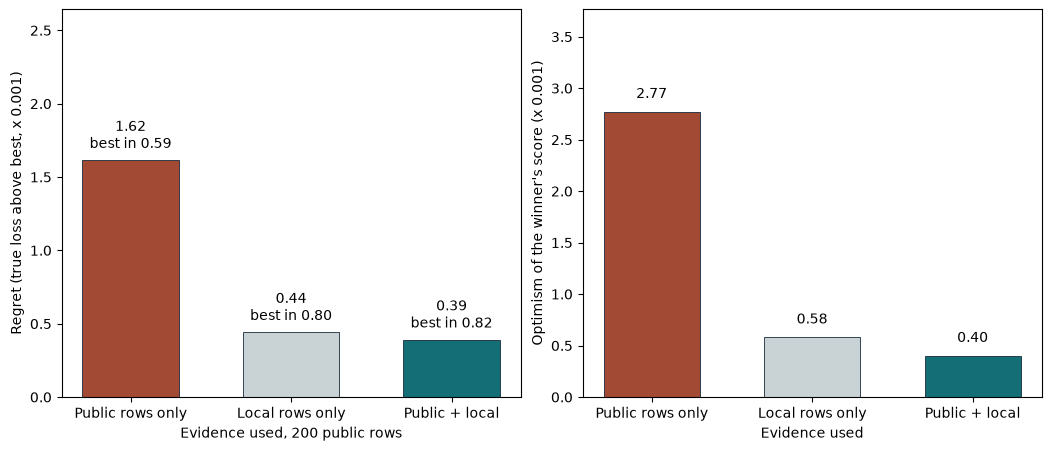

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch18 import draw, NCOLS, HEIGHT

DEFAULT = 0.1
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 200 public rows out of 2000, the public rule submits the best of 12 candidates in 0.594 of splits and the 1000-row local rule in 0.796. Mean regret is 0.00162 against 0.00044, so 0.00162 - 0.00044 = 0.00118. Local rows pick better than the 200 public rows. Pooling gives 0.00039. The public winner's score is 0.00277 better than its true loss, so a winning public score overstates it.

- Public rows only: best candidate picked in 0.594 of splits, regret 0.00162.
- Local rows only: best candidate picked in 0.796 of splits, regret 0.00044.
- Pooled rows: best candidate picked in 0.818 of splits, regret 0.00039.
- Public minus pooled regret: 0.00162 - 0.00039 = 0.00123.

## Apply this to your competition

- Freeze a champion from paired, local evidence before reading the public leaderboard, and write the evidence down.
- Treat the public leaderboard as a block of rows: weight it by its size, and pool it with local evidence rather than replacing it.
- When candidates differ by less than the noise of the rows that scored them, prefer the simpler or the more recoverable one.
- Do not read the winner's public score as its expected private score: the selected candidate's score is flattered by the selection.

Book location: Chapter 18, Simulating Public/Private Split Stability.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)